In [1]:
import os
import warnings

import agama
import astropy
import cmasher as cmr
import gc_utils
import gizmo_analysis as gizmo
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import utilities as ut
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm, Normalize
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import stats
from scipy.interpolate import griddata, interp1d
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit, minimize
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde, lognorm, norm
from sklearn.svm import SVC, LinearSVC

agama.setUnits(mass=1, length=1, velocity=1)
units = agama.getUnits()

# plt.rc("font", family="Nimbus Roman")
plt.rc("font", family="Nimbus Roman No9 L")

SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [2]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
sim_cmap = plt.get_cmap("tab10")
sim_colors = [sim_cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

sim_dir = "/Users/z5114326/Documents/simulations/"

snap = 600

public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
snap_lst = np.array(pub_data["index"])
time_lst = np.array(pub_data["time_Gyr"])
timez0 = np.array(pub_data["time_Gyr"])[-1]

In [3]:
sim_dict = {}
for sim in sim_lst:
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    ghost_data = h5py.File(ghost_file, "r")

    sim_dict[sim] = {}
    for it_id in ghost_data.keys():
        src_dat = ghost_data[it_id]["source"]

        amsk = src_dat["grpid"][()] == 0
        grpid = src_dat["grpid"][()]
        samsk = src_dat["sa_flag"][()]

        m_tfo = 10 ** src_dat["logm_tfor"][()]
        m_tfo_ev = 0.55 * (10 ** src_dat["logm_tfor"][()])

        m_tz0_log = src_dat["logm_tz0"][()]
        m_tz0 = np.array([10**x if x != -1 else 0 for x in m_tz0_log])

        tfor = src_dat["tfor"][()]
        tdis = src_dat["tdis"][()]
        tacc = src_dat["tacc"][()]

        r_bir = src_dat["halo.r.birth"][()]

        age = timez0 - tfor
        age_p = np.array([x - y if x != -1 else timez0 - y for x, y in zip(tdis, tfor)])

        t_tz0 = src_dat["torb_600"][()]
        s_tz0 = np.array(src_dat["s_flag"][()], dtype=bool)

        ml = m_tfo_ev - m_tz0
        ml_rate = (m_tfo_ev - m_tz0) / age_p

        sim_dict[sim][it_id] = {}
        sim_dict[sim][it_id]["m_tfo"] = m_tfo
        sim_dict[sim][it_id]["m_tfo_ev"] = m_tfo_ev
        sim_dict[sim][it_id]["m_tz0"] = m_tz0
        sim_dict[sim][it_id]["tfor"] = tfor
        sim_dict[sim][it_id]["tdis"] = tdis
        sim_dict[sim][it_id]["tacc"] = tacc
        sim_dict[sim][it_id]["age"] = age
        sim_dict[sim][it_id]["age_p"] = age_p
        sim_dict[sim][it_id]["t_tz0"] = t_tz0
        sim_dict[sim][it_id]["s_tz0"] = s_tz0
        sim_dict[sim][it_id]["ml"] = ml
        sim_dict[sim][it_id]["ml_rate"] = ml_rate
        sim_dict[sim][it_id]["acc"] = amsk
        sim_dict[sim][it_id]["grp"] = grpid
        sim_dict[sim][it_id]["samsk"] = samsk
        sim_dict[sim][it_id]["r_bir"] = r_bir

In [4]:
mass_dict = {sim: {it_id: {} for it_id in sim_dict[sim].keys()} for sim in sim_lst}

for sim in mass_dict.keys():
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    ghost_data = h5py.File(ghost_file, "r")

    for it_id in sim_dict[sim].keys():
        src_dat = ghost_data[it_id]["source"]
        smsk = src_dat["s_flag"][()].astype(bool)

        gcids = src_dat["gcid"][smsk]
        taccs = src_dat["tacc"][smsk]
        tfors = src_dat["tfor"][smsk]
        mtfors = 10 ** src_dat["logm_tfor"][smsk]
        mtforevs = 0.55 * mtfors

        grps = src_dat["grpid"][smsk]

        samsks = src_dat["sa_flag"][smsk].astype(bool)
        amsks = src_dat["grpid"][()] == 0

        data_dict = {
            gcid: {
                "t_snp": [],
                "m_snp": [],
                "tacc": tacc,
                "tfor": tfor,
                "mtfor": mtfor,
                "mtforev": mtforev,
                "samsk": samsk,
                "amsk": amsk,
                "grp": grp,
            }
            for gcid, tacc, tfor, mtfor, mtforev, samsk, amsk, grp in zip(
                gcids, taccs, tfors, mtfors, mtforevs, samsks, amsks, grps
            )
        }

        for snap in snap_lst:
            snap_id = gc_utils.snapshot_name(snap)
            time = float(pub_data[pub_data["index"] == snap]["time_Gyr"].values[0])

            snp_dat = ghost_data[it_id]["snapshots"][snap_id]
            gcids_snp = snp_dat["gcid"][()]
            mass_snp = 10 ** snp_dat["logm"][()]

            gcid_msk = np.isin(gcids_snp, gcids)
            gc_snp_dict = {gcids_snp[idx]: idx for idx in np.nonzero(gcid_msk)[0]}

            for gcid in gcids:
                if gcid not in gcids_snp:
                    data_dict[gcid]["m_snp"].append(np.nan)
                    data_dict[gcid]["t_snp"].append(np.nan)
                    continue
                gcidx = gc_snp_dict[gcid]
                data_dict[gcid]["m_snp"].append(mass_snp[gcidx])
                data_dict[gcid]["t_snp"].append(time)

        mass_dict[sim][it_id] = data_dict

for sim in sim_lst:
    for it_id in mass_dict[sim].keys():
        for gcid in mass_dict[sim][it_id].keys():
            # extract masses and times, remove NaNs
            masses = np.array(mass_dict[sim][it_id][gcid]["m_snp"])
            times = np.array(mass_dict[sim][it_id][gcid]["t_snp"])
            valid = ~np.isnan(masses) & ~np.isnan(times)
            masses = masses[valid]
            times = times[valid]

            # add formation mass/time at start
            masses = np.insert(masses, 0, mass_dict[sim][it_id][gcid]["mtforev"])
            times = np.insert(times, 0, mass_dict[sim][it_id][gcid]["tfor"])

            # remove tiny dt intervals, keep last point
            dt = np.diff(times)
            # mask = np.insert(dt > 0.01, 0, True)  # keep first point, remove very tiny intervals
            mask = np.append(dt > 0.01, True)  # keep last point, remove very tiny intervals
            masses_clean = masses[mask]
            times_clean = times[mask]

            mass_dict[sim][it_id][gcid]["mass_clean"] = masses_clean
            mass_dict[sim][it_id][gcid]["time_clean"] = times_clean

for sim in sim_lst:
    for it_id in mass_dict[sim].keys():
        for gcid in mass_dict[sim][it_id].keys():
            mass = mass_dict[sim][it_id][gcid]["mass_clean"]
            time = mass_dict[sim][it_id][gcid]["time_clean"]

            gamma_mov = []
            for i in range(1, len(mass)):
                gamma_mov_i = (1 / (time[i] - time[i - 1])) * np.log(mass[i - 1] / mass[i])
                gamma_mov.append(gamma_mov_i)

            mass_dict[sim][it_id][gcid]["gamma_mov"] = np.array(gamma_mov)

In [5]:
# sim = "m12i"
# it_id = "it001"

# mfmin = 5
# mfmax = 5.5

# tfmin = 2
# tfmax = 4

# tamin = 10
# tamax = 12

# for gcid in mass_dict[sim][it_id].keys():
#     tfor = mass_dict[sim][it_id][gcid]["tfor"]
#     tacc = mass_dict[sim][it_id][gcid]["tacc"]
#     mfor = mass_dict[sim][it_id][gcid]["mtfor"]
#     mfor_log = np.log10(mfor)

#     smsk = mass_dict[sim][it_id][gcid]["mtfor"]

#     if (mfor_log < mfmin) or (mfmax <= mfor_log):
#         continue
#     if (tfor < tfmin) or (tfmax <= tfor):
#         continue
#     if (tacc < tamin) or (tamax <= tacc):
#         print(tacc)
#         continue

#     gamma_mov = mass_dict[sim][it_id][gcid]["gamma_mov"]
#     time = mass_dict[sim][it_id][gcid]["time_clean"]

#     plt.plot(time[1:], gamma_mov, c="grey")

In [6]:
# sim = "m12i"
# it_id = "it001"

# mmin = 6
# mmax = 6.5

# tmin = 2
# tmax = 4

# dt = np.diff(time_lst)
# # mask = np.insert(dt > 0.01, 0, True)  # keep first point, remove very tiny intervals
# mask = np.append(dt > 0.01, True)  # keep last point, remove very tiny intervals
# time_arr = time_lst[mask]

# hld_arr = []

# for gcid in mass_dict[sim][it_id].keys():
#     tfor = mass_dict[sim][it_id][gcid]["tfor"]
#     tacc = mass_dict[sim][it_id][gcid]["tacc"]
#     mfor = mass_dict[sim][it_id][gcid]["mtfor"]
#     mfor_log = np.log10(mfor)

#     if (mfor_log < mfmin) or (mfmax <= mfor_log):
#         continue
#     if (tfor < tmin) or (tmax <= tfor):
#         continue

#     gamma_mov = mass_dict[sim][it_id][gcid]["gamma_mov"]
#     time = mass_dict[sim][it_id][gcid]["time_clean"]

#     gamma_mov_full = np.full(len(time_arr), np.nan)

#     idx = np.isin(time_arr, time[1:])
#     gamma_mov_full[idx] = gamma_mov

#     hld_arr.append(gamma_mov_full)

# # convert to array
# hld_arr = np.array(hld_arr)

In [7]:
mfor_bins = np.arange(4, 7.5, 0.5)
tfor_bins = np.arange(0, 14, 2)
tacc_bins = np.arange(0, 16, 2)

In [8]:
sim = "m12i"
it_id = "it001"

mmin = 5
mmax = 5.5

tmin = 2
tmax = 4

tacc_bins = np.arange(0, 16, 2)

dt = np.diff(time_lst)
mask = np.append(dt > 0.01, True)
time_arr = time_lst[mask]

# containers
group_dict = {"in_situ": []}

for i in range(len(tacc_bins) - 1):
    group_dict[f"ex_situ_{tacc_bins[i]}_{tacc_bins[i + 1]}"] = []

# loop over clusters
for gcid in mass_dict[sim][it_id].keys():
    tfor = mass_dict[sim][it_id][gcid]["tfor"]
    tacc = mass_dict[sim][it_id][gcid]["tacc"]
    mfor = mass_dict[sim][it_id][gcid]["mtfor"]
    mfor_log = np.log10(mfor)

    if (mfor_log < mmin) or (mmax <= mfor_log):
        continue
    if (tfor < tmin) or (tmax <= tfor):
        continue

    gamma_mov = mass_dict[sim][it_id][gcid]["gamma_mov"]
    time = mass_dict[sim][it_id][gcid]["time_clean"]

    gamma_mov_full = np.full(len(time_arr), np.nan)

    idx = np.isin(time_arr, time[1:])
    gamma_mov_full[idx] = gamma_mov

    # -------------------
    # classify GC
    # -------------------

    if tacc == -1:
        group_dict["in_situ"].append(gamma_mov_full)

    else:
        bin_i = np.digitize(tacc, tacc_bins) - 1

        if 0 <= bin_i < len(tacc_bins) - 1:
            key = f"ex_situ_{tacc_bins[bin_i]}_{tacc_bins[bin_i + 1]}"
            group_dict[key].append(gamma_mov_full)

# convert to arrays
for key in group_dict:
    group_dict[key] = np.array(group_dict[key])

/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_56709/2001795952.py:4: RuntimeWarning: Mean of empty slice
  plt.plot(time_arr, np.nanmean(group_dict[key], axis=0), label=key)


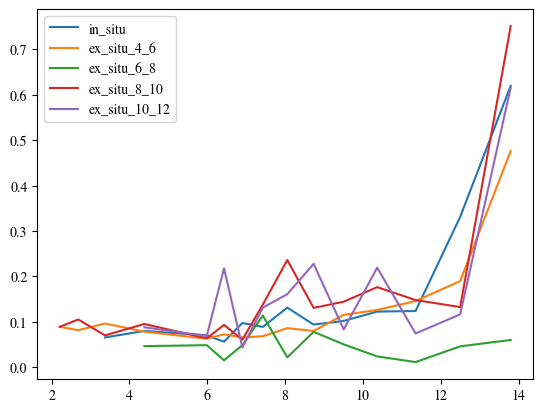

In [9]:
for key in group_dict:
    if len(group_dict[key]) == 0:
        continue
    plt.plot(time_arr, np.nanmean(group_dict[key], axis=0), label=key)
plt.legend()

In [10]:
# sim = "m12i"
# it_id = "it001"

# tacc_bins = np.arange(0, 16, 2)
# plot_dict = {f"ex_situ_{tacc_bins[i]}_{tacc_bins[i + 1]}": [] for i in range(len(tacc_bins) - 1)}

# for it_id in mass_dict[sim].keys():
#     for gcid in mass_dict[sim][it_id].keys():
#         if mass_dict[sim][it_id][gcid]["tacc"] == -1:
#             continue



In [11]:
sim_dict[sim][it_id].keys()

dict_keys(['m_tfo', 'm_tfo_ev', 'm_tz0', 'tfor', 'tdis', 'tacc', 'age', 'age_p', 't_tz0', 's_tz0', 'ml', 'ml_rate', 'acc', 'grp', 'samsk', 'r_bir'])

In [12]:
sim = "m12i"
it_id = "it001"

age_bins = np.arange(0, 15, 1)
tacc_bins = np.arange(0, 16, 2)

s_tz0 = sim_dict[sim][it_id]["s_tz0"]

amsk = sim_dict[sim][it_id]["acc"][s_tz0]
tacc = sim_dict[sim][it_id]["tacc"][s_tz0]

tfor = sim_dict[sim][it_id]["tfor"][s_tz0]
m_tfo_ev = sim_dict[sim][it_id]["m_tfo_ev"][s_tz0]
m_tz0 = sim_dict[sim][it_id]["m_tz0"][s_tz0]

age = tfor

gamma = (1 / (timez0 - tfor)) * np.log(m_tfo_ev / m_tz0)


plot_dict = {
    f"ex_situ_{tacc_bins[i]}_{tacc_bins[i + 1]}": {"gamma": None, "age": None}
    for i in range(len(tacc_bins) - 1)
}
for i in range(1, len(tacc_bins)):
    tamin = tacc_bins[i - 1]
    tamax = tacc_bins[i]

    tamsk = (tamin <= tacc) & (tacc < tamax)

    plot_dict[f"ex_situ_{tacc_bins[i - 1]}_{tacc_bins[i]}"]["gamma"] = gamma[tamsk & ~amsk]
    plot_dict[f"ex_situ_{tacc_bins[i - 1]}_{tacc_bins[i]}"]["age"] = age[tamsk & ~amsk]

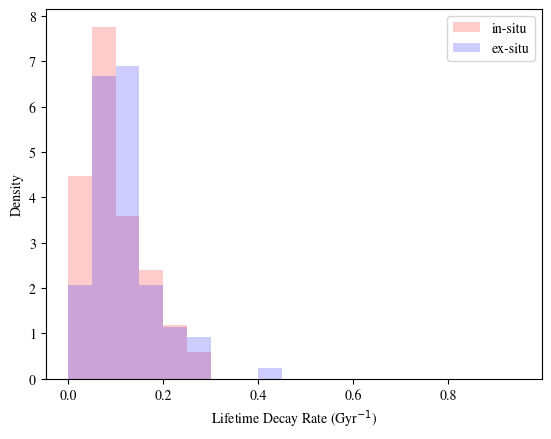

In [13]:
# sim = "m12m"

in_arr = np.array([])
ex_arr = np.array([])

for it_id in sim_dict[sim].keys():
    smsk = sim_dict[sim][it_id]["s_tz0"]
    amsk = sim_dict[sim][it_id]["acc"][smsk]

    tfor = sim_dict[sim][it_id]["tfor"][smsk]
    m_tfo_ev = sim_dict[sim][it_id]["m_tfo_ev"][smsk]
    m_tz0 = sim_dict[sim][it_id]["m_tz0"][smsk]

    age = timez0 - tfor

    gamma = (1 / (age)) * np.log(m_tfo_ev / m_tz0)
    # gamma = ((m_tfo_ev - m_tz0) / m_tfo_ev) / age

    in_arr = np.append(in_arr, gamma[amsk])
    ex_arr = np.append(ex_arr, gamma[~amsk])


bins = np.arange(0, 1, 0.05)
# bins = np.arange(0, 0.1, 0.005)
plt.hist(gamma[amsk], color="r", alpha=0.2, label="in-situ", density=True, bins=bins)
plt.hist(gamma[~amsk], color="b", alpha=0.2, label="ex-situ", density=True, bins=bins)

plt.ylabel("Density")
plt.xlabel("Lifetime Decay Rate (Gyr$^{-1}$)")

plt.legend()

In [16]:
# mass_dict[sim][it_id][gcid].keys()

In [17]:
# loop over clusters
for sim in mass_dict.keys():
    for it_id in mass_dict[sim].keys():
        for gcid in mass_dict[sim][it_id].keys():
            tacc = mass_dict[sim][it_id][gcid]["tacc"]
            tfor = mass_dict[sim][it_id][gcid]["tfor"]
            if tacc == -1:
                continue

            masses = mass_dict[sim][it_id][gcid]["mass_clean"]
            times = mass_dict[sim][it_id][gcid]["time_clean"]

            if len(masses) <= 1 or len(times) <= 1:
                mass_dict[sim][it_id][gcid]["gamma_pre"] = np.nan
                mass_dict[sim][it_id][gcid]["gamma_pos"] = np.nan
                mass_dict[sim][it_id][gcid]["gamma_ful"] = np.nan
                continue

            f_cubic = interp1d(times, masses, kind="cubic")

            mforev = mass_dict[sim][it_id][gcid]["mtforev"]
            macc = f_cubic(tacc)
            mz0 = mass_dict[sim][it_id][gcid]["m_snp"][-1]

            if mforev <= 0 or macc <= 0 or mz0 <= 0:
                gamma_pre = np.nan
                gamma_pos = np.nan
                gamma_ful = np.nan
            else:
                gamma_pre = (1 / (tacc - tfor)) * np.log(mforev / macc)
                gamma_pos = (1 / (timez0 - tacc)) * np.log(macc / mz0)
                gamma_ful = (1 / (timez0 - tfor)) * np.log(mforev / mz0)

            mass_dict[sim][it_id][gcid]["gamma_pre"] = gamma_pre
            mass_dict[sim][it_id][gcid]["gamma_pos"] = gamma_pos
            mass_dict[sim][it_id][gcid]["gamma_ful"] = gamma_ful

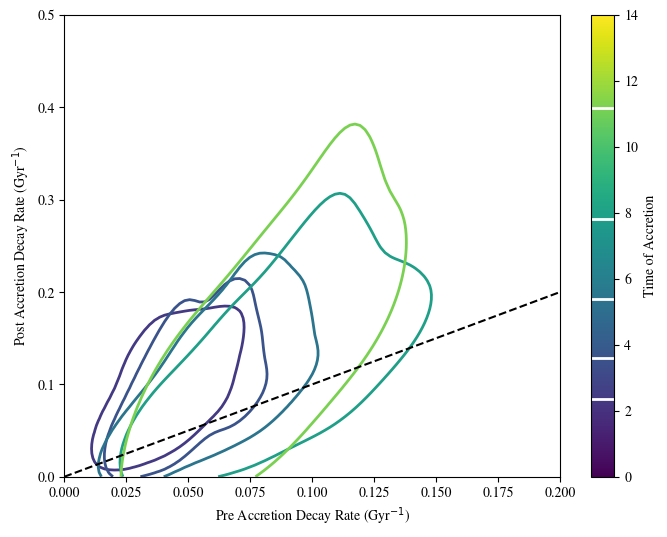

In [21]:
sim = "m12i"

# --------------------------------------------------
# PARAMETERS
# --------------------------------------------------
xlim = (0, 0.2)
# ylim = (0, 0.85)
ylim = (0, 0.5)
min_gc_per_grp_avg = 5  # average minimum GCs per group across iterations
epsilon = 1e-6  # tiny jitter for KDE stability
cmap = plt.get_cmap("viridis")  # colormap

# --------------------------------------------------
# COMPUTE GROUP COUNTS AND TACC ACROSS ITERATIONS
# --------------------------------------------------
grp_counts = {}  # key = grp, value = list of counts per iteration
grp_tacc = {}  # key = grp, value = list of tacc values

for it_id in mass_dict[sim].keys():
    counts_in_it = {}
    for gcid in mass_dict[sim][it_id].keys():
        grp = mass_dict[sim][it_id][gcid]["grp"]
        tacc = mass_dict[sim][it_id][gcid]["tacc"]
        if tacc == -1:
            continue
        counts_in_it[grp] = counts_in_it.get(grp, 0) + 1
        grp_tacc.setdefault(grp, []).append(tacc)
    # append counts per iteration
    for grp, cnt in counts_in_it.items():
        grp_counts.setdefault(grp, []).append(cnt)

# Only keep groups with average ≥ min_gc_per_grp_avg
valid_grps = [grp for grp, counts in grp_counts.items() if np.mean(counts) >= min_gc_per_grp_avg]

# --------------------------------------------------
# BIN DATA BY GROUP
# --------------------------------------------------
binned_data = {grp: {"gamma_pre": [], "gamma_pos": [], "tacc": None} for grp in valid_grps}

for grp in valid_grps:
    # mean tacc for the group
    binned_data[grp]["tacc"] = np.mean(grp_tacc[grp])

for it_id in mass_dict[sim].keys():
    for gcid in mass_dict[sim][it_id].keys():
        grp = mass_dict[sim][it_id][gcid]["grp"]
        if grp not in valid_grps:
            continue  # skip invalid groups
        tacc = mass_dict[sim][it_id][gcid]["tacc"]
        if tacc == -1:
            continue  # only accreted GCs
        binned_data[grp]["gamma_pre"].append(mass_dict[sim][it_id][gcid]["gamma_pre"])
        binned_data[grp]["gamma_pos"].append(mass_dict[sim][it_id][gcid]["gamma_pos"])


# --------------------------------------------------
# FUNCTION TO COMPUTE 75% KDE LEVEL
# --------------------------------------------------
def kde_contour_level(z, frac=0.75):
    z_sorted = np.sort(z.ravel())[::-1]
    cumsum = np.cumsum(z_sorted)
    cumsum /= cumsum[-1]
    idx = np.searchsorted(cumsum, frac)
    return z_sorted[idx]


# --------------------------------------------------
# PLOT CONTOURS
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# Normalize colormap by tacc
all_tacc = [data["tacc"] for data in binned_data.values()]
if len(all_tacc) == 0:
    raise RuntimeError("No valid groups to plot! Check your min_gc_per_grp_avg or data.")
norm = plt.Normalize(vmin=0, vmax=14)

for grp, data in binned_data.items():
    x = np.array(data["gamma_pre"])
    y = np.array(data["gamma_pos"])

    # Remove NaNs/Infs
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        continue

    # tiny jitter
    x += np.random.normal(0, epsilon, len(x))
    y += np.random.normal(0, epsilon, len(y))

    # KDE
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)

    # Grid
    xgrid = np.linspace(*xlim, 100)
    ygrid = np.linspace(*ylim, 100)
    X, Y = np.meshgrid(xgrid, ygrid)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    # 75% contour
    level_75 = kde_contour_level(Z, frac=0.75)
    ax.contour(X, Y, Z, levels=[level_75], colors=[cmap(norm(data["tacc"]))], linewidths=2)

# --------------------------------------------------
# COLORBAR & FINAL TOUCHES
# --------------------------------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Time of Accretion")

ax.plot([0, 1], [0, 1], "k--")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel("Pre Accretion Decay Rate (Gyr$^{-1}$)")
ax.set_ylabel("Post Accretion Decay Rate (Gyr$^{-1}$)")


# Put ticks on top (optional, looks nicer for top colorbar)
# cax.xaxis.set_ticks_position("top")
# cax.xaxis.set_label_position("top")

for tacc in all_tacc:
    cbar.ax.axhline(tacc, color="w", lw=2.0, ls="-")

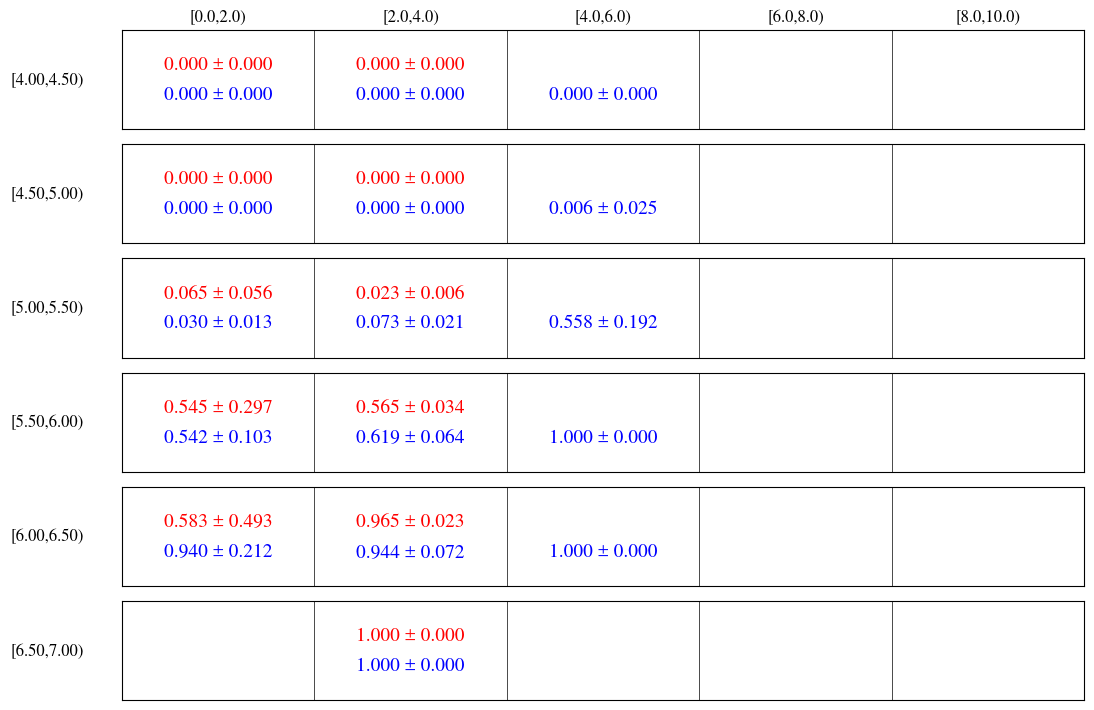

In [ ]:
sim = "m12m"

tfor_bins = np.arange(0, 12, 2)
mfor_bins = 10 ** np.arange(4, 7.5, 0.5)

data_arr = np.empty(shape=(len(mfor_bins) - 1, len(tfor_bins) - 1), dtype=object)
for i, j in np.ndindex(data_arr.shape):
    data_arr[i, j] = {"in-situ": None, "ex-situ": None}

for i, j in np.ndindex(data_arr.shape):
    mfor_min = mfor_bins[i]
    mfor_max = mfor_bins[i + 1]

    tfor_min = tfor_bins[j]
    tfor_max = tfor_bins[j + 1]

    in_hld_lst = []
    ex_hld_lst = []
    for it_id in sim_dict[sim].keys():
        amsk = sim_dict[sim][it_id]["acc"][()]
        smsk = sim_dict[sim][it_id]["s_tz0"][()]
        samsk = sim_dict[sim][it_id]["samsk"][()].astype(bool)
        samsk = np.ones(len(smsk), dtype=bool)

        mfor = sim_dict[sim][it_id]["m_tfo"][()]
        tfor = sim_dict[sim][it_id]["tfor"][()]

        mmsk = (mfor_min <= mfor) & (mfor < mfor_max)
        tmsk = (tfor_min <= tfor) & (tfor < tfor_max)

        if np.sum(amsk & mmsk & tmsk) == 0:
            in_hld_lst.append(np.nan)
        else:
            in_hld_lst.append(np.sum(amsk & smsk & mmsk & tmsk) / np.sum(amsk & mmsk & tmsk))

        if np.sum(~amsk & mmsk & tmsk) == 0:
            ex_hld_lst.append(np.nan)
        else:
            ex_hld_lst.append(
                np.sum(~amsk & smsk & mmsk & tmsk & samsk) / np.sum(~amsk & mmsk & tmsk & samsk)
            )

    if np.all(np.isnan(in_hld_lst)):
        in_avg = np.nan
        in_std = np.nan
    else:
        in_avg = np.nanmean(in_hld_lst)
        in_std = np.nanstd(in_hld_lst)

    if np.all(np.isnan(ex_hld_lst)):
        ex_avg = np.nan
        ex_std = np.nan
    else:
        ex_avg = np.nanmean(ex_hld_lst)
        ex_std = np.nanstd(ex_hld_lst)

    data_arr[i, j]["in-situ"] = {"avg": in_avg, "std": in_std}
    data_arr[i, j]["ex-situ"] = {"avg": ex_avg, "std": ex_std}

n_m = len(mfor_bins) - 1
n_t = len(tfor_bins) - 1

fig, axs = plt.subplots(nrows=n_m, ncols=1, figsize=(2.2 * n_t, 1.2 * n_m), sharex=False)

if n_m == 1:
    axs = [axs]

for i in range(n_m):
    ax = axs[i]
    ax.set_xlim(0, n_t)
    ax.set_ylim(0, 1)

    ax.set_xticks([])
    ax.set_yticks([])

    # ---- Mass bin label (left side) ----
    mmin = np.log10(mfor_bins[i])
    mmax = np.log10(mfor_bins[i + 1])

    ax.text(-0.2, 0.5, f"[{mmin:.2f},{mmax:.2f})", va="center", ha="right", fontsize=12)
    # ax.text(-0.2, 0.5, f"{mmin:.2f} $\leq$ log$_{10}$ $M_\star$ / M_\odot < {mmax:.2f}", va="center", ha="right", fontsize=10, rotate = 90)

    for j in range(n_t):
        avg_in = data_arr[i, j]["in-situ"]["avg"]
        std_in = data_arr[i, j]["in-situ"]["std"]

        avg_ex = data_arr[i, j]["ex-situ"]["avg"]
        std_ex = data_arr[i, j]["ex-situ"]["std"]

        x = j + 0.5

        # ---- In-situ (top, red) ----
        if not np.isnan(avg_in):
            ax.text(
                x, 0.65, f"{avg_in:.3f} ± {std_in:.3f}", ha="center", va="center", color="red", fontsize=14
            )

        # ---- Ex-situ (bottom, blue) ----
        if not np.isnan(avg_ex):
            ax.text(
                x, 0.35, f"{avg_ex:.3f} ± {std_ex:.3f}", ha="center", va="center", color="blue", fontsize=14
            )

    # vertical separators
    for xline in range(n_t + 1):
        ax.axvline(xline, color="black", lw=0.5)

    ax.axhline(0, color="black", lw=0.5)
    ax.axhline(1, color="black", lw=0.5)

# ---- Column labels on top row ----
top_ax = axs[0]

for j in range(n_t):
    tmin = tfor_bins[j]
    tmax = tfor_bins[j + 1]

    top_ax.text(j + 0.5, 1.05, f"[{tmin:.1f},{tmax:.1f})", ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------
# Settings
# ------------------------
sim = "m12i"
cont_level = 0.95
hist_density = False

hist_label = "Avgerage GC Count"

# ------------------------
# Figure & axes
# ------------------------
fig, ax_scatter = plt.subplots(figsize=(9, 7))
divider = make_axes_locatable(ax_scatter)

ax_histx = divider.append_axes("top", 1.2, pad=0.15, sharex=ax_scatter)
ax_histy = divider.append_axes("right", 1.2, pad=0.15, sharey=ax_scatter)

# ------------------------
# Reference lines
# ------------------------
x_fit = np.logspace(4, 7.1)
ax_scatter.plot(x_fit, 0.55 * x_fit, c="grey", lw=0.75, ls="--")
ax_scatter.plot(x_fit, x_fit, c="grey", lw=0.75)

# ------------------------
# KDE grid (log–log)
# ------------------------
logx_grid = np.linspace(2, 7.2, 200)
logy_grid = np.linspace(2, 7.2, 200)
XX, YY = np.meshgrid(logx_grid, logy_grid)
grid_positions = np.vstack([XX.ravel(), YY.ravel()])

# ------------------------
# Histogram bins
# ------------------------
histx_bins = np.logspace(3, 7, 41)
histy_bins = np.logspace(1, 7, 61)

# ------------------------
# Histogram accumulators
# ------------------------
hist_dict = {
    "in-situ": {"x_sum": None, "y_sum": None, "n_iter": 0},
    "ex-situ": {"x_sum": None, "y_sum": None, "n_iter": 0},
}

# ------------------------
# Main loop
# ------------------------
for acc in [0, 1]:
    if acc == 0:
        acc_lab = "in-situ"
        color = "r"
    else:
        acc_lab = "ex-situ"
        color = "b"

    Z_list = []

    for it_id in sim_dict[sim].keys():
        smsk = sim_dict[sim][it_id]["s_tz0"]

        if acc == 0:
            amsk = sim_dict[sim][it_id]["acc"]
        else:
            amsk = ~sim_dict[sim][it_id]["acc"]

        msk = smsk & amsk

        x = sim_dict[sim][it_id]["m_tfo"][msk]
        y = sim_dict[sim][it_id]["m_tz0"][msk]

        # Enforce physical bound
        bound = y <= 0.55 * x
        x = x[bound]
        y = y[bound]

        if len(x) < 20:
            continue

        # ------------------------
        # KDE (per iteration)
        # ------------------------
        logx = np.log10(x)
        logy = np.log10(y)

        kde = gaussian_kde(np.vstack([logx, logy]))
        Z = kde(grid_positions).reshape(XX.shape)

        Z /= Z.sum()  # equal weight per iteration
        Z_list.append(Z)

        # ------------------------
        # Histograms (per iteration)
        # ------------------------
        hx, _ = np.histogram(x, bins=histx_bins)
        hy, _ = np.histogram(y, bins=histy_bins)

        if hist_dict[acc_lab]["x_sum"] is None:
            hist_dict[acc_lab]["x_sum"] = hx.astype(float)
            hist_dict[acc_lab]["y_sum"] = hy.astype(float)
        else:
            hist_dict[acc_lab]["x_sum"] += hx
            hist_dict[acc_lab]["y_sum"] += hy

        hist_dict[acc_lab]["n_iter"] += 1

    if len(Z_list) == 0:
        continue

    # ------------------------
    # Average KDE
    # ------------------------
    Z_avg = np.mean(Z_list, axis=0)

    # Mask unphysical region
    log_bound = np.log10(0.55) + XX
    Z_avg[YY > log_bound] = 0

    # ------------------------
    # Contour level
    # ------------------------
    Zf = Z_avg.ravel()
    idx = np.argsort(Zf)[::-1]
    Zs = Zf[idx]

    cdf = np.cumsum(Zs)
    cdf /= cdf[-1]

    level = Zs[np.searchsorted(cdf, cont_level)]

    ax_scatter.contour(
        10**XX,
        10**YY,
        Z_avg,
        levels=[level],
        colors=color,
        linewidths=2,
    )

# ------------------------
# Legend
# ------------------------
ax_scatter.legend(
    handles=[
        Line2D([0], [0], color="r", lw=2, label="in-situ surviving"),
        Line2D([0], [0], color="b", lw=2, label="ex-situ surviving"),
    ],
    frameon=False,
)

# ------------------------
# Average histograms
# ------------------------
hist_avg = {}
for acc_lab in ["in-situ", "ex-situ"]:
    n = hist_dict[acc_lab]["n_iter"]
    hist_avg[acc_lab] = {
        "x": hist_dict[acc_lab]["x_sum"] / n,
        "y": hist_dict[acc_lab]["y_sum"] / n,
    }

# X histogram
ax_histx.step(histx_bins[:-1], hist_avg["in-situ"]["x"], where="post", color="r")
ax_histx.step(histx_bins[:-1], hist_avg["ex-situ"]["x"], where="post", color="b")
# ax_histx.set_yscale("log")
ax_histx.set_ylabel(hist_label)
ax_histx.tick_params(labelbottom=False)
ax_histx.set_yticks([0, 5, 10, 15])
ax_histx.set_ylim([0, 16])

# Y histogram
ax_histy.step(hist_avg["in-situ"]["y"], histy_bins[:-1], where="post", color="r")
ax_histy.step(hist_avg["ex-situ"]["y"], histy_bins[:-1], where="post", color="b")
# ax_histy.set_xscale("log")
ax_histy.set_xlabel(hist_label)
ax_histy.tick_params(labelleft=False)
ax_histy.set_xticks([0, 5, 10])
ax_histy.set_xlim([0, 11])

# ------------------------
# Axes formatting
# ------------------------
ax_scatter.set_xscale("log")
ax_scatter.set_yscale("log")
ax_scatter.set_xlim(1e4, 10**7.1)
ax_scatter.set_ylim(1e2, 10**7.1)
ax_scatter.set_xlabel(r"Mass at Formation ($M_\odot$)")
ax_scatter.set_ylabel(r"Mass at $z=0$ ($M_\odot$)")
